<a href="https://colab.research.google.com/github/jhonn18git/inteligencia-artificial-1-ia/blob/main/laboratorios/lab2/lab_2_regresion_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicion de programación - Regresión Logistica

En este laboratorio se entrenaron diferentes modelos de regresión utilizando un dataset de física de partículas.

El dataset contiene más de 20000 ejemplos y más de 20 características físicas que describen eventos detectados en experimentos de colisión de partículas.

Se entrenaron tres modelos diferentes:

• Regresión lineal multivariable  
• Regresión polinómica  
• Ecuación de la normal  

El objetivo del modelo es clasificar eventos como señal (signal) o fondo (background).  
La señal corresponde a eventos físicos relevantes mientras que el fondo corresponde a eventos normales o ruido del detector.

Durante el entrenamiento se analizaron los gráficos de costo para verificar la convergencia del algoritmo.  
Finalmente se realizaron más de 100 predicciones para evaluar la efectividad del modelo.

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# Librerías básicas de computación
import numpy as np
import pandas as pd

# Librerías para graficar
from matplotlib import pyplot as plt

# Librería de optimización
from scipy import optimize

# Le indica a matplotlib que los gráficos se muestren en el notebook
%matplotlib inline

In [41]:
import pandas as pd
# Cargar el dataset de Particle Physics
data = pd.read_csv('/content/drive/MyDrive/colab/lab2/Particle Physics Event Classification.csv')

# Mostrar las primeras filas
print("Primeras filas del dataset:")
display(data.head())

Primeras filas del dataset:


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [42]:
# Eliminar filas con valores faltantes
data = data.dropna()

print("Datos después de limpiar vacíos:")
print(data.shape)

Datos después de limpiar vacíos:
(250000, 33)


In [43]:
X = data.drop(columns=['Label']).values  # Todas las columnas excepto 'Label'

# Variable objetivo (0=fondo, 1=señal)
y = data['Label'].apply(lambda x: 1 if x == 's' else 0).values

# Número de ejemplos
m = y.size
print("Cantidad de ejemplos:", m)
print("Primeros datos de X:")
print(X[:5])

Cantidad de ejemplos: 250000
Primeros datos de X:
[[ 1.00000000e+05  1.38470000e+02  5.16550000e+01  9.78270000e+01
   2.79800000e+01  9.10000000e-01  1.24711000e+02  2.66600000e+00
   3.06400000e+00  4.19280000e+01  1.97760000e+02  1.58200000e+00
   1.39600000e+00  2.00000000e-01  3.26380000e+01  1.01700000e+00
   3.81000000e-01  5.16260000e+01  2.27300000e+00 -2.41400000e+00
   1.68240000e+01 -2.77000000e-01  2.58733000e+02  2.00000000e+00
   6.74350000e+01  2.15000000e+00  4.44000000e-01  4.60620000e+01
   1.24000000e+00 -2.47500000e+00  1.13497000e+02  2.65331100e-03]
 [ 1.00001000e+05  1.60937000e+02  6.87680000e+01  1.03235000e+02
   4.81460000e+01 -9.99000000e+02 -9.99000000e+02 -9.99000000e+02
   3.47300000e+00  2.07800000e+00  1.25157000e+02  8.79000000e-01
   1.41400000e+00 -9.99000000e+02  4.20140000e+01  2.03900000e+00
  -3.01100000e+00  3.69180000e+01  5.01000000e-01  1.03000000e-01
   4.47040000e+01 -1.91600000e+00  1.64546000e+02  1.00000000e+00
   4.62260000e+01  7.2500

In [44]:
def normalizar_caracteristicas(X):
    """
    Normaliza cada característica para tener media 0 y desviación estándar 1.
    Esto ayuda al modelo a entrenar más rápido.
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

In [45]:
X_norm, mu, sigma = normalizar_caracteristicas(X)

print("Media de cada característica:", mu[:5], "...")  # mostrar solo primeras 5
print("Desviación estándar de cada característica:", sigma[:5], "...")

Media de cada característica: [ 2.24999500e+05 -4.90230794e+01  4.92398193e+01  8.11819816e+01
  5.78959617e+01] ...
Desviación estándar de cada característica: [7.21687836e+04 4.06344834e+02 3.53448149e+01 4.08286089e+01
 6.36555543e+01] ...


In [46]:
X_ready = np.concatenate([np.ones((m,1)), X_norm], axis=1)
print("Shape de X_ready:", X_ready.shape)

Shape de X_ready: (250000, 33)


In [47]:
def sigmoid(z):
    """
    Calcula la función sigmoide: g(z) = 1 / (1 + e^-z)
    """
    return 1 / (1 + np.exp(-z))

In [48]:
def costFunction(theta, X, y):
    """
    Calcula el costo y el gradiente de regresión logística.
    """
    m = y.size
    h = sigmoid(np.dot(X, theta))

    # Costo
    J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))

    # Gradiente
    grad = (1/m) * np.dot(X.T, (h - y))

    return J, grad


In [49]:
# Inicializar theta en ceros
initial_theta = np.zeros(X_ready.shape[1])

# Optimizar theta usando el método TNC
res = optimize.minimize(fun=costFunction,
                        x0=initial_theta,
                        args=(X_ready, y),
                        jac=True,
                        method='TNC',
                        options={'maxiter': 300})

theta = res.x
cost_final = res.fun

print("Theta calculado:")
print(theta[:5], "...")  # mostrar solo primeros 5 valores
print("Costo final:", cost_final)

/tmp/ipykernel_160/4254031553.py:5: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(fun=costFunction,
/tmp/ipykernel_160/2882191388.py:9: RuntimeWarning: divide by zero encountered in log
  J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
/tmp/ipykernel_160/2882191388.py:9: RuntimeWarning: invalid value encountered in multiply
  J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))


Theta calculado:
[-4.11933267 -0.00752942 -0.12976362 -1.22558356 -0.40352802] ...
Costo final: 0.25807292373636215


In [50]:
def predict(theta, X):
    """
    Predice 0 o 1 usando regresión logística.
    """
    return np.round(sigmoid(np.dot(X, theta)))

In [51]:
predicciones = predict(theta, X_ready)
precision = np.mean(predicciones == y) * 100

print("Precisión del modelo en los datos de entrenamiento: {:.2f}%".format(precision))

Precisión del modelo en los datos de entrenamiento: 90.52%


In [54]:
import numpy as np
def sigmoid(z):
    """
    Calcula la función sigmoide: g(z) = 1 / (1 + e^-z)
    """
    return 1 / (1 + np.exp(-z))

# Tomar el primer evento
evento = X[0]

# Normalizar
evento_norm = (evento - mu) / sigma

# Agregar columna de unos (bias)
evento_ready = np.concatenate(([1], evento_norm))

# Calcular probabilidad y predicción
prob = sigmoid(np.dot(evento_ready, theta))
pred = np.round(prob)

print("Probabilidad de que sea señal:", prob)
print("Predicción del modelo (0=fondo, 1=señal):", int(pred))

Probabilidad de que sea señal: 0.3449207695430257
Predicción del modelo (0=fondo, 1=señal): 0


In [55]:

# En este modelo intentamos aproximar la relación entre
# las características del evento (X) y la variable objetivo (y)
# usando una combinación lineal de los parámetros theta.

# Función que calcula el costo del modelo de regresión lineal
def calcularCosto(X, y, theta):

    # Número de ejemplos del dataset
    m = y.size

    # Fórmula del costo de regresión lineal
    # mide qué tan lejos están las predicciones del valor real
    J = (1/(2*m)) * np.sum((np.dot(X, theta) - y)**2)

    return J


# Implementación del algoritmo de Gradiente Descendente
# Este algoritmo ajusta los parámetros theta poco a poco
# para minimizar el error del modelo
def descensoGradiente(X, y, theta, alpha, iteraciones):

    # Número de ejemplos
    m = y.size

    # Lista para guardar el costo en cada iteración
    J_hist = []

    # Bucle de entrenamiento
    for i in range(iteraciones):

        # Actualización de los parámetros theta
        theta = theta - (alpha/m) * (np.dot(X,theta) - y).dot(X)

        # Guardamos el costo actual para graficar después
        J_hist.append(calcularCosto(X,y,theta))

    return theta, J_hist

In [56]:

# ENTRENAMIENTO DEL MODELO DE REGRESIÓN LINEAL

# Inicializamos los parámetros theta con ceros
theta_lin = np.zeros(X_ready.shape[1])

# Tasa de aprendizaje
alpha = 0.01

# Número de iteraciones del algoritmo
iteraciones = 400

# Ejecutamos el gradiente descendente
theta_lin, J_hist_lin = descensoGradiente(X_ready, y, theta_lin, alpha, iteraciones)

# Mostramos los primeros valores de theta calculados
print("Theta regresión lineal:")
print(theta_lin[:5])

Theta regresión lineal:
[ 3.36516920e-01 -1.53862381e-04  3.64630720e-03 -5.38383351e-02
 -1.09504041e-02]


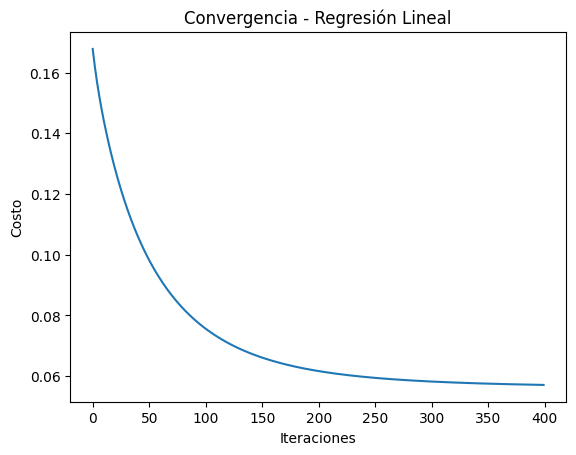

In [57]:
# ==============================================
# GRÁFICO DEL COSTO DEL MODELO LINEAL
# ==============================================
# Este gráfico permite ver cómo el error del modelo
# disminuye a medida que avanza el entrenamiento.

plt.plot(J_hist_lin)

plt.xlabel("Iteraciones")      # eje X = número de iteraciones
plt.ylabel("Costo")           # eje Y = error del modelo
plt.title("Convergencia - Regresión Lineal")

plt.show()

In [58]:
# REGRESIÓN POLINÓMICA

# En este modelo agregamos términos polinómicos (X^2)
# para capturar relaciones no lineales entre variables.

# Elevamos cada característica al cuadrado
X_poly = X_norm**2

# Unimos las características originales con las polinómicas
X_poly = np.concatenate([X_norm, X_poly], axis=1)

# Agregamos la columna de unos para el bias
X_poly = np.concatenate([np.ones((m,1)), X_poly], axis=1)

# Mostramos el tamaño del nuevo dataset
print("Shape polinómico:", X_poly.shape)

Shape polinómico: (250000, 65)


In [61]:
# ENTRENAMIENTO DEL MODELO POLINÓMICO


# Inicializamos theta
theta_poly = np.zeros(X_poly.shape[1])

# Usamos un alpha más pequeño para evitar overflow
alpha_poly = 0.00001

# Ejecutamos gradiente descendente
theta_poly, J_hist_poly = descensoGradiente(X_poly, y, theta_poly, alpha_poly, iteraciones)

print("Theta polinómico:")
print(theta_poly[:5])

Theta polinómico:
[ 1.28935872e-03  4.26111629e-06  4.47077989e-04 -6.64367706e-04
 -3.48272287e-05]


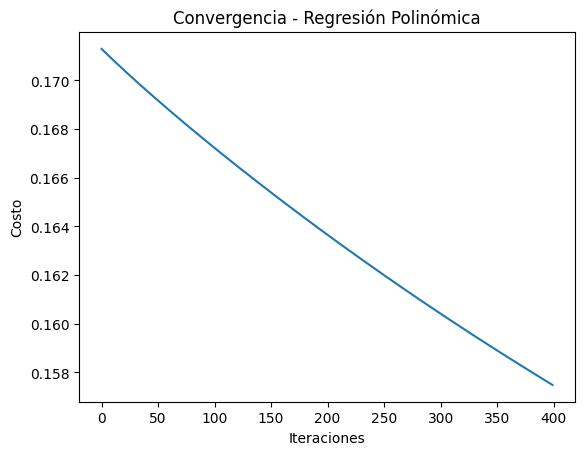

In [62]:
# ==============================================
# GRÁFICO DEL COSTO POLINÓMICO
# ==============================================
# Permite comparar cómo aprende el modelo polinómico.

plt.plot(J_hist_poly)

plt.xlabel("Iteraciones")
plt.ylabel("Costo")
plt.title("Convergencia - Regresión Polinómica")

plt.show()

In [63]:
# ECUACIÓN NORMAL

# Este método calcula directamente los parámetros theta
# usando álgebra matricial sin usar gradiente descendente.

# Fórmula: theta = (X^T X)^(-1) X^T y

theta_normal = np.linalg.inv(X_ready.T.dot(X_ready)).dot(X_ready.T).dot(y)

print("Theta ecuación normal:")
print(theta_normal[:5])

Theta ecuación normal:
[ 3.42668000e-01 -2.33819245e-04 -7.68376959e-03 -4.70645868e-02
 -2.88761728e-02]


In [64]:

# REALIZAR PREDICCIONES

# Usamos el modelo lineal entrenado para predecir
# si un evento es señal (1) o fondo (0)

print("Primeras 100 predicciones del modelo")

# Calculamos predicciones usando theta del modelo lineal
pred = np.round(np.dot(X_ready, theta_lin))

# Mostramos las primeras 100 predicciones
for i in range(100):

    print("Ejemplo", i+1,
          "Real:", y[i],        # valor real
          "Predicho:", int(pred[i]))   # valor predicho

Primeras 100 predicciones del modelo
Ejemplo 1 Real: 1 Predicho: 0
Ejemplo 2 Real: 0 Predicho: 0
Ejemplo 3 Real: 0 Predicho: 0
Ejemplo 4 Real: 0 Predicho: 0
Ejemplo 5 Real: 0 Predicho: 0
Ejemplo 6 Real: 0 Predicho: 0
Ejemplo 7 Real: 1 Predicho: 1
Ejemplo 8 Real: 1 Predicho: 1
Ejemplo 9 Real: 0 Predicho: 0
Ejemplo 10 Real: 1 Predicho: 1
Ejemplo 11 Real: 0 Predicho: 0
Ejemplo 12 Real: 0 Predicho: 0
Ejemplo 13 Real: 0 Predicho: 0
Ejemplo 14 Real: 0 Predicho: 0
Ejemplo 15 Real: 0 Predicho: 0
Ejemplo 16 Real: 1 Predicho: 1
Ejemplo 17 Real: 0 Predicho: 0
Ejemplo 18 Real: 1 Predicho: 1
Ejemplo 19 Real: 0 Predicho: 0
Ejemplo 20 Real: 0 Predicho: 0
Ejemplo 21 Real: 0 Predicho: 0
Ejemplo 22 Real: 0 Predicho: 0
Ejemplo 23 Real: 0 Predicho: 0
Ejemplo 24 Real: 1 Predicho: 1
Ejemplo 25 Real: 0 Predicho: 0
Ejemplo 26 Real: 0 Predicho: 0
Ejemplo 27 Real: 1 Predicho: 1
Ejemplo 28 Real: 1 Predicho: 1
Ejemplo 29 Real: 1 Predicho: 1
Ejemplo 30 Real: 0 Predicho: 1
Ejemplo 31 Real: 0 Predicho: 0
Ejemplo 32 

In [65]:
# =====================================================
# CÁLCULO DE LA PRECISIÓN DEL MODELO
# =====================================================
# Comparamos cuántas predicciones fueron correctas.

accuracy_lin = np.mean(pred == y) * 100

print("Precisión del modelo lineal:", accuracy_lin,"%")

Precisión del modelo lineal: 89.8164 %


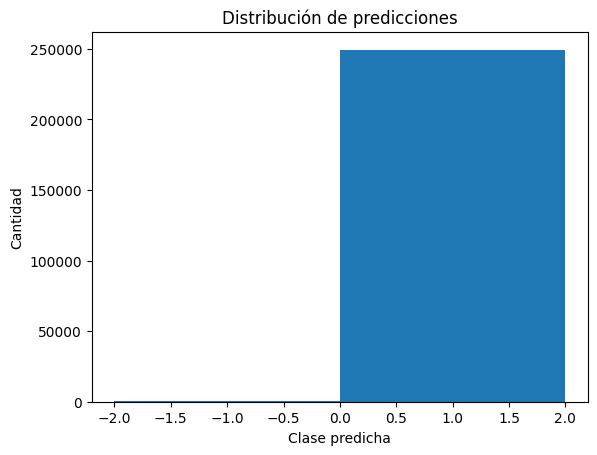

In [66]:
# =====================================================
# DISTRIBUCIÓN DE LAS PREDICCIONES
# =====================================================
# Este gráfico muestra cuántos eventos fueron clasificados
# como señal y cuántos como fondo.

plt.hist(pred, bins=2)

plt.title("Distribución de predicciones")

plt.xlabel("Clase predicha")
plt.ylabel("Cantidad")

plt.show()

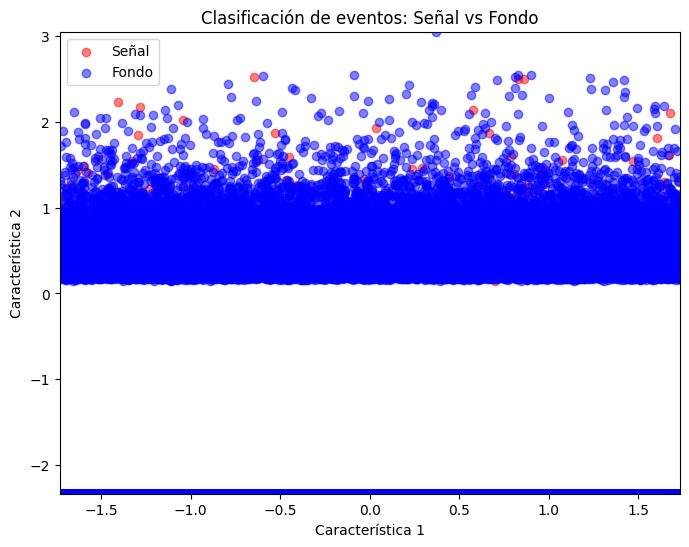

In [67]:
# =====================================================
# VISUALIZACIÓN DE CLASIFICACIÓN (SEÑAL VS FONDO)
# =====================================================
# Usaremos solo 2 características para poder graficar
# (por ejemplo las dos primeras del dataset)

x1 = X_norm[:,0]
x2 = X_norm[:,1]

# Graficar los puntos del dataset
plt.figure(figsize=(8,6))

# Señal (1) -> rojo
plt.scatter(x1[y==1], x2[y==1], c='red', label='Señal', alpha=0.5)

# Fondo (0) -> azul
plt.scatter(x1[y==0], x2[y==0], c='blue', label='Fondo', alpha=0.5)

# Crear malla para graficar la frontera de decisión
u = np.linspace(min(x1), max(x1), 100)
v = np.linspace(min(x2), max(x2), 100)

z = np.zeros((len(u), len(v)))

for i in range(len(u)):
    for j in range(len(v)):

        # Crear vector de entrada usando solo dos variables
        x_temp = np.zeros(X_ready.shape[1])
        x_temp[0] = 1          # bias
        x_temp[1] = u[i]
        x_temp[2] = v[j]

        # Calcular valor del modelo
        z[i,j] = np.dot(x_temp, theta)

# Transponer para que matplotlib lo entienda
z = z.T

# Dibujar la frontera de decisión
plt.contour(u, v, z, levels=[0], linewidths=2)

plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Clasificación de eventos: Señal vs Fondo")

plt.legend()
plt.show()